# SGIMC Simulation Tuning

Pairwise-CV protocol (same as the HPC masked scripts): 

outer doCrossValidationByPairwise on the OBSERVED matrix R_noisy, 

nested inner CV for HP selection, 

outer test scored against the clean truth R. 

Parallelised by opening several notebooks, each owning a slice of DATASET_IDS.

## Cell 1 — Configure which datasets this notebook runs

In [2]:
# ============================================================
# USER SETTINGS — change these per notebook instance
# ============================================================

# A unique label for this notebook — used in the output filename
# e.g. 'nb0', 'nb1', 'nb2' ... open one notebook per label
NOTEBOOK_ID = "nb1"

# Which dataset_grid indices (i_ds) this notebook will process.
# dataset_grid has 100 entries (10 feature sizes x 10 repeats),
# indexed 0..99. Split them across notebooks however you like.
#
# Example splits across 4 notebooks:
#   nb0: list(range(0,  25))   # feature_id 0-1, all repeats
#   nb1: list(range(25, 50))   # feature_id 2-3, all repeats
#   nb2: list(range(50, 75))   # feature_id 4-6, all repeats
#   nb3: list(range(75, 100))  # feature_id 7-9, all repeats
#
# Or by repeat_id if you prefer:
#   nb0: [i for i in range(100) if (i % 10) < 5]   # repeat_id 0-4
#   nb1: [i for i in range(100) if (i % 10) >= 5]  # repeat_id 5-9

DATASET_IDS = list(range(0, 1))  # <-- change this per notebook

BASE_SEED = 123456  # must match HPC runs for reproducible splits

# ============================================================

## Cell 2 — Paths

In [3]:
import os
import sys
import gzip
import pickle
import warnings
import logging

import numpy as np
from tqdm import TqdmSynchronisationWarning, tqdm

warnings.simplefilter("ignore", TqdmSynchronisationWarning)

# ====== user paths — adjust to your local machine ======
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"  # <-- change to local root
PATH_DATA = os.path.join(PATH_ROOT, "datasets/simulations/masked_ones")
PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/simulations/masked_ones")
PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
DRIMC_PATH = os.path.join(PATH_ROOT, "scripts/methods/DRIMC")

for p in (PATH_OUTPUT, PATH_ARCHIVE):
    os.makedirs(p, exist_ok=True)

sys.path.append(PATH_ROOT)

print(f"Output will be saved to: {PATH_OUTPUT}")
print(f"Notebook ID: {NOTEBOOK_ID}  |  Datasets to run: {len(DATASET_IDS)}")

Output will be saved to: /Users/sijianfan/projects/BiSSGL/outputs/results/simulations/masked_ones
Notebook ID: nb1  |  Datasets to run: 1


## Cell 3 — Imports

In [5]:
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import ParameterGrid, train_test_split
from scipy.special import expit
from scipy.sparse import coo_matrix

from sgimc import SparseGroupIMCClassifier

## Cell 4 — R setup via rpy2

In [6]:
import rpy2.robjects as robjects

r = robjects.r
r(f'setwd("{DRIMC_PATH}")')

for pkg in ["matrixcalc", "data.table", "Rcpp", "ROCR", "Bolstad2", "MESS"]:
    r(f"library({pkg})")

for r_file in [
    "doCrossValidationByPairwise.R",
    "constrNeig.R",
    "calcLogLik.R",
    "calcDeriv.R",
    "updateUV.R",
]:
    r(f'source("{r_file}")')

r("library(Rcpp)")
for cpp_file in ["log1pexp.cpp", "sigmoid.cpp"]:
    r(f'sourceCpp("{cpp_file}")')

doCrossValidationByPairwise_R = r["doCrossValidationByPairwise"]
updateUV_R = r["updateUV"]
constrNeig_R = r["constrNeig"]
print("R setup complete.")

R callback write-console: data.table 1.17.8 using 6 threads (see ?getDTthreads).    
R callback write-console: Latest news: r-datatable.com
  


R setup complete.


## Cell 5 — Helper functions

In [7]:
def get_metrics(real_score, predict_score):
    sorted_predict_score = np.array(
        sorted(list(set(np.array(predict_score).flatten())))
    )
    sorted_predict_score_num = len(sorted_predict_score)
    thresholds = sorted_predict_score[
        np.int32(sorted_predict_score_num * np.arange(1, 1000) / 1000)
    ]
    thresholds = np.mat(thresholds)
    thresholds_num = thresholds.shape[1]
    predict_score_matrix = np.tile(predict_score, (thresholds_num, 1))
    negative_index = np.where(predict_score_matrix < thresholds.T)
    positive_index = np.where(predict_score_matrix >= thresholds.T)
    predict_score_matrix[negative_index] = 0
    predict_score_matrix[positive_index] = 1
    TP = predict_score_matrix.dot(real_score.T)
    FP = predict_score_matrix.sum(axis=1) - TP
    FN = real_score.sum() - TP
    TN = len(real_score.T) - TP - FP - FN
    fpr = FP / (FP + TN)
    tpr = TP / (TP + FN)
    ROC_dot_matrix = np.mat(sorted(np.column_stack((fpr, tpr)).tolist())).T
    ROC_dot_matrix.T[0] = [0, 0]
    ROC_dot_matrix = np.c_[ROC_dot_matrix, [1, 1]]
    x_ROC = ROC_dot_matrix[0].T
    y_ROC = ROC_dot_matrix[1].T
    auc = 0.5 * (x_ROC[1:] - x_ROC[:-1]).T * (y_ROC[:-1] + y_ROC[1:])
    recall_list = tpr
    precision_list = TP / (TP + FP)
    PR_dot_matrix = np.mat(
        sorted(np.column_stack((recall_list, precision_list)).tolist())
    ).T
    PR_dot_matrix.T[0] = [0, 1]
    PR_dot_matrix = np.c_[PR_dot_matrix, [1, 0]]
    x_PR = PR_dot_matrix[0].T
    y_PR = PR_dot_matrix[1].T
    aupr = 0.5 * (x_PR[1:] - x_PR[:-1]).T * (y_PR[:-1] + y_PR[1:])
    f1_score_list = 2 * TP / (len(real_score.T) + TP - TN)
    accuracy_list = (TP + TN) / len(real_score.T)
    specificity_list = TN / (TN + FP)
    max_index = np.argmax(f1_score_list)
    f1_score = f1_score_list[max_index]
    accuracy = accuracy_list[max_index]
    specificity = specificity_list[max_index]
    recall = recall_list[max_index]
    precision = precision_list[max_index]
    return [aupr[0, 0], auc[0, 0], f1_score, accuracy, recall, specificity, precision]

# ====== variable-selection accuracy vs the known truth ======
def selection_scores(est, n_true, tol=0.0):
    """Variable-selection metrics for a coefficient matrix `est` (d, K).

    A feature (row of `est`) is 'selected' if its row is not all-zero
    (max |.| > tol), matching the d1/d2 definition. The first `n_true`
    features are the ground-truth informative ones (the generator puts the
    signal in the first n_true columns of X and Y).

    Note: with many noise features, plain accuracy is dominated by true
    negatives -- recall, precision and f1 are the informative quantities.
    """
    d = est.shape[0]
    selected = np.abs(est).max(axis=1) > tol  # (d,) bool
    truth = np.zeros(d, dtype=bool)
    truth[:n_true] = True

    TP = int(np.sum(selected & truth))
    FP = int(np.sum(selected & ~truth))
    FN = int(np.sum(~selected & truth))
    TN = int(np.sum(~selected & ~truth))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # = TP / n_true
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "accuracy": (TP + TN) / d,
        "precision": precision,
        "recall": recall,  # sensitivity / TPR over the true features
        "specificity": specificity,
        "f1": f1,
        "n_selected": int(np.sum(selected)),
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
    }

def to_r_matrix(arr):
    return r.matrix(
        robjects.FloatVector(arr.flatten()),
        byrow=True,
        nrow=arr.shape[0],
        ncol=arr.shape[1],
    )


def build_sim_matrices(U, V, K=3):
    simD = 1 - pairwise_distances(U[:, 0:24], metric="jaccard")
    simT = 1 - pairwise_distances(V[:, 0:24], metric="jaccard")
    simD = np.nan_to_num(simD, nan=0.0)
    simT = np.nan_to_num(simT, nan=0.0)
    np.fill_diagonal(simD, 1.0)
    np.fill_diagonal(simT, 1.0)
    lap = constrNeig_R(to_r_matrix(simD), to_r_matrix(simT), K=K)
    simD_R = lap.rx2("simD")
    simT_R = lap.rx2("simT")
    return np.array(simD_R), np.array(simT_R), simD_R, simT_R  # constrained np + R


def extract_fold(savedFolds, trial, fold):
    fold_data = savedFolds.rx2(trial + 1).rx2(fold + 1)
    Y_train = np.array(fold_data.rx2(7))
    test_label = np.array(fold_data.rx2(1)).flatten()
    test_row = np.array(fold_data.rx2(3)).flatten().astype(int) - 1
    test_col = np.array(fold_data.rx2(4)).flatten().astype(int) - 1
    known_drug_idx = np.array(fold_data.rx2(5)).flatten().astype(int)
    known_target_idx = np.array(fold_data.rx2(6)).flatten().astype(int)
    return Y_train, test_row, test_col, test_label, known_drug_idx, known_target_idx

_data_cache = {}  # i_ds -> (U, V, R_true, R_obs)
_outer_folds_cache = {}  # i_ds -> savedFolds (R object) for R_obs
_inner_folds_cache = {}  # (i_ds, fold) -> inner savedFolds (R object)

def load_dataset(i_ds, ds):
    if i_ds not in _data_cache:
        with gzip.open(ds["filename"], "rb") as fin:
            data = pickle.load(fin)
        U = np.asarray(data["X"], dtype=float)
        V = np.asarray(data["Y"], dtype=float)
        R_true = np.asarray(data["R"], dtype=float)  # clean truth {0,1}
        R_obs = np.asarray(data["R_noisy"], dtype=float)  # observed {0,1}
        _data_cache[i_ds] = (U, V, R_true, R_obs)
    return _data_cache[i_ds]


def outer_folds(i_ds, R_obs):
    if i_ds not in _outer_folds_cache:
        seed = (BASE_SEED + i_ds * 7919) % (2**31 - 1)
        _outer_folds_cache[i_ds] = doCrossValidationByPairwise_R(
            to_r_matrix(R_obs),
            kfold=KFOLD,
            numSplit=NUMSPLIT_OUTER,
            seeds=robjects.IntVector([seed]),
        )
    return _outer_folds_cache[i_ds]

# ====== {0,1} foldMat -> fully-observed {-1,+1} sparse matrix ======
def to_pm_sparse(fold_dense):
    pm = np.where(np.asarray(fold_dense) >= 0.5, 1.0, -1.0)
    return coo_matrix(pm)


print("Helpers defined.")

Helpers defined.


## Cell 6 — Build grids

In [279]:
n_features_grid = np.arange(50, 501, 50)
n_repeats = 10
filename_template = "data_feature_{:03d}_rep_{:02d}.gz"

dataset_grid = []
for feature_id, n_features in enumerate(n_features_grid):
    for repeat_id in range(n_repeats):
        dataset_grid.append(
            {
                "feature_id": int(feature_id),
                "n_features": int(n_features),
                "repeat_id": int(repeat_id),
                "filename": os.path.join(
                    PATH_DATA, filename_template.format(n_features, repeat_id)
                ),
            }
        )

# CV config
KFOLD = 10
NUMSPLIT_OUTER = 1
N_INNER_KFOLD = 10
N_INNER_EVAL = 3
DO_INNER_CV = False
N_RANK = 25  # number of informative (true) features: first N_RANK rows of est_A/est_B

# ====== model hyperparameter grid (SGIMC) ======
grid_model = ParameterGrid(
    {
        "C_lasso": [6.0],
        "C_group": [2.0],
        "C_ridge": [1.0],
        "rank": [25],
    }
)

n_m = len(list(grid_model))

my_ids = list(DATASET_IDS)
print(f"Datasets assigned : {len(my_ids)}")
print(f"Folds per dataset : {KFOLD}")
print(f"Hyperparam combos : {n_m}")
print(f"Total fits (outer): {len(my_ids) * KFOLD * n_m}")

combos = []
for i_ds, ds in enumerate(dataset_grid):
    for fold in range(KFOLD):
        for i_m, par_mdl in enumerate(grid_model):
            combos.append((i_ds, fold, i_m, ds, par_mdl))
n_combos = len(combos)

combo_idx = 500

i_ds, fold, i_m, ds, par_mdl = combos[combo_idx]
U, V, R_true, R_obs = load_dataset(i_ds, ds)
savedFolds = outer_folds(i_ds, R_obs)

Y_train_dense, test_row, test_col, _obs_label, _, _ = extract_fold(
    savedFolds, 0, fold
)
test_label_true = R_true[test_row, test_col]

C_lasso = par_mdl["C_lasso"]
C_group = par_mdl["C_group"]
C_ridge = par_mdl["C_ridge"]
rank = par_mdl["rank"]

combos[combo_idx]
model_seed = BASE_SEED + combo_idx

Datasets assigned : 1
Folds per dataset : 10
Hyperparam combos : 1
Total fits (outer): 10


## Cell 7 — Run

Progress bars are shown per dataset.  
Results are **incrementally saved** after each dataset finishes — if the kernel dies mid-run you keep completed datasets.

In [280]:
# SGIMC: {-1,+1}, fully-observed foldMat
model = SparseGroupIMCClassifier(
    rank,
    n_threads=-1,
    random_state=model_seed,
    C_lasso=C_lasso,
    C_group=C_group,
    C_ridge=C_ridge,
)
model.fit(U, V, to_pm_sparse(Y_train_dense))

prob_full = np.asarray(model.predict_proba(U, V))
prob_test = prob_full[test_row, test_col]
scores_test = get_metrics(
    np.asarray(test_label_true, dtype=float),
    np.asarray(prob_test, dtype=float),
)
d1_test = int(sum(abs(model.coef_W_).max(axis=1) > 0))
d2_test = int(sum(abs(model.coef_H_).max(axis=1) > 0))
sel_A = np.where(abs(model.coef_W_).max(axis=1) > 0)[0].astype(int).tolist()
sel_B = np.where(abs(model.coef_H_).max(axis=1) > 0)[0].astype(int).tolist()
sel_acc_A = selection_scores(model.coef_W_, N_RANK)
sel_acc_B = selection_scores(model.coef_H_, N_RANK)

<StemContainer object of 3 artists>

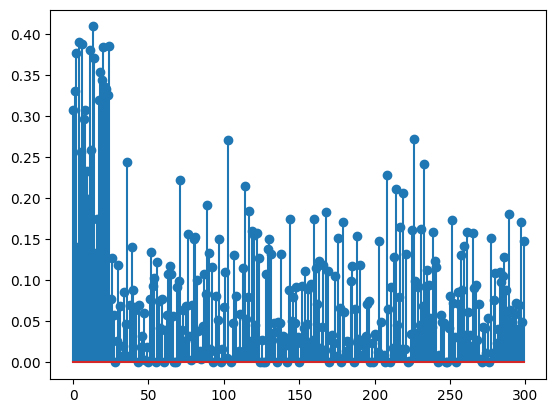

In [281]:
import matplotlib.pyplot as plt
plt.stem(np.abs(model.coef_W_).mean(axis=1))

In [282]:
task_results = []
task_results.append(
                {
                    "feature_id": ds["feature_id"],
                    "n_features": ds["n_features"],
                    "repeat_id": ds["repeat_id"],
                    "fold": int(fold),
                    "C_lasso": C_lasso,
                    "C_group": C_group,
                    "C_ridge": C_ridge,
                    "rank": rank,
                    "test_score": scores_test,
                    "test_d1": d1_test,
                    "test_d2": d2_test,
                    # "test_sel_A": sel_A,
                    # "test_sel_B": sel_B,
                    "test_selacc_A": sel_acc_A,
                    "test_selacc_B": sel_acc_B,
                }
            )


task_results

[{'feature_id': 5,
  'n_features': 300,
  'repeat_id': 0,
  'fold': 0,
  'C_lasso': 6.0,
  'C_group': 2.0,
  'C_ridge': 1.0,
  'rank': 25,
  'test_score': [0.05037835015136763,
   0.7424167647388478,
   0.11295180722891567,
   0.9515832929936887,
   0.2269670477471419,
   0.9615601851851852,
   0.07518378257963912],
  'test_d1': 273,
  'test_d2': 273,
  'test_selacc_A': {'accuracy': 0.17333333333333334,
   'precision': 0.09157509157509157,
   'recall': 1.0,
   'specificity': 0.09818181818181818,
   'f1': 0.16778523489932887,
   'n_selected': 273,
   'TP': 25,
   'FP': 248,
   'FN': 0,
   'TN': 27},
  'test_selacc_B': {'accuracy': 0.17333333333333334,
   'precision': 0.09157509157509157,
   'recall': 1.0,
   'specificity': 0.09818181818181818,
   'f1': 0.16778523489932887,
   'n_selected': 273,
   'TP': 25,
   'FP': 248,
   'FN': 0,
   'TN': 27}}]